# AI-Driven Intrusion Detection System — Pipeline v10
**Uses separate train.csv and test.csv files.**
**v10 upgrade: 7-class grouped classification (attack families instead of 15 individual types).**

| Label | Group | Original Attack Types |
|-------|-------|-----------------------|
| 0 | BENIGN | BENIGN |
| 1 | Web Attacks | Brute Force, XSS, SQL Injection |
| 2 | DoS | Hulk, GoldenEye, Slowloris, Slowhttptest |
| 3 | DDoS | DDoS |
| 4 | PortScan | PortScan |
| 5 | Bot/Patator | Bot, FTP-Patator, SSH-Patator |
| 6 | Rare/Others | Infiltration, Heartbleed |

**v6 changes:** Logistic Regression switched to `saga` solver with `n_jobs=-1` for significantly faster training and lower RAM usage on large datasets. Removed deprecated `use_label_encoder` from XGBoost. Removed redundant `f1_score` import in Step 13.

**v7 changes:** SMOTE capped at 10,000 samples per minority class (prevents dataset explosion). Random Forest reduced to 50 estimators. Logistic Regression `tol=1e-3` for faster convergence.

**v8 changes:** All models and arrays saved to disk immediately after each step. Resume cell added — run it after any kernel restart to reload everything without retraining.

**v9 changes:** Removed SMOTE entirely. Replaced with `class_weight="balanced"` on LR and RF, and `sample_weight` on XGBoost. Faster training, lower RAM, better real-world generalisation on rare attack classes.

**v10 changes:** Replaced 15 individual attack classes with 7 grouped categories (attack families). Original `Label` column mapped to group ID via `GROUP_MAP` before training.


## STEP 1 — Install Libraries (run once only)

In [1]:
# Remove the # below, run once, then add the # back
# !pip install pandas numpy scikit-learn matplotlib seaborn xgboost joblib imbalanced-learn

## STEP 2 — Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score,
    precision_score, recall_score, f1_score
)

# SMOTE removed in v9 — class_weight='balanced' used instead (faster, no synthetic data)

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
    print('✅ XGBoost available')
except ImportError:
    XGBOOST_AVAILABLE = False
    print('⚠️  XGBoost not available — pip install xgboost')

print('\nAll libraries imported!')


✅ XGBoost available

All libraries imported!


## ⚡ RESUME — Reload from disk after kernel restart
Run **only this cell** if your kernel restarted and you want to skip straight to evaluation/visualisation steps.  
All training steps save their outputs to disk, so you never need to retrain from scratch.


In [3]:
import joblib, numpy as np
import warnings; warnings.filterwarnings('ignore')

# ── Reload arrays ──────────────────────────────────────────────────────────
X_train = np.load('X_train.npy')
y_train = np.load('y_train.npy')
X_test  = np.load('X_test.npy')
y_test  = np.load('y_test.npy')

# ── Reload metadata ────────────────────────────────────────────────────────
scaler      = joblib.load('scaler.pkl')
available   = joblib.load('feature_columns.pkl')
LABEL_MAP   = joblib.load('label_map.pkl')
GROUP_MAP   = joblib.load('group_map.pkl')
CLASS_NAMES = joblib.load('class_names.pkl')
NUM_CLASSES = len(LABEL_MAP)  # 7

# ── Reload models ──────────────────────────────────────────────────────────
lr  = joblib.load('logistic_regression_model.pkl')
rf  = joblib.load('random_forest_model.pkl')
iso = joblib.load('isolation_forest_model.pkl')

try:
    xgb = joblib.load('xgboost_model.pkl')
    XGBOOST_AVAILABLE = True
except FileNotFoundError:
    XGBOOST_AVAILABLE = False

# ── Recompute predictions (needed for eval/viz steps) ─────────────────────
lr_pred   = lr.predict(X_test)
lr_proba  = lr.predict_proba(X_test)
rf_pred   = rf.predict(X_test)
rf_proba  = rf.predict_proba(X_test)
iso_raw   = iso.predict(X_test)
iso_pred  = np.where(iso_raw == -1, 1, 0)
iso_score = -iso.score_samples(X_test)
if XGBOOST_AVAILABLE:
    xgb_pred  = xgb.predict(X_test)
    xgb_proba = xgb.predict_proba(X_test)

print('✅ All models, arrays, and predictions reloaded from disk.')
print(f'   X_train : {X_train.shape}')
print(f'   X_test  : {X_test.shape}')
print(f'   Models loaded: LR, RF, IsoForest' + (', XGBoost' if XGBOOST_AVAILABLE else ''))


FileNotFoundError: [Errno 2] No such file or directory: 'X_train.npy'

## STEP 3 — Load train.csv and test.csv

In [4]:
# Load training data
df_train = pd.read_csv('train.csv', encoding='utf-8', low_memory=False)
df_train.columns = df_train.columns.str.strip()
print(f'Train loaded: {df_train.shape[0]:,} rows, {df_train.shape[1]} columns')

# Load test data
df_test = pd.read_csv('test.csv', encoding='utf-8', low_memory=False)
df_test.columns = df_test.columns.str.strip()
print(f'Test  loaded: {df_test.shape[0]:,} rows, {df_test.shape[1]} columns')


Train loaded: 2,059,411 rows, 80 columns
Test  loaded: 514,853 rows, 80 columns


## STEP 4 — Label Mapping (7-Class Groups)
Map the original numeric `Label` (0–14) to 7 grouped attack-family labels.
All original traffic types are retained — just consolidated into families.


Train group distribution:
GroupLabel
BENIGN         1718709
DoS             154998
DDoS            102413
PortScan         72655
Bot/Patator       8883
Web Attacks       1715
Rare/Others         38
Name: count, dtype: int64

Test group distribution:
GroupLabel
BENIGN         429677
DoS             38750
DDoS            25603
PortScan        18164
Bot/Patator      2222
Web Attacks       428
Rare/Others         9
Name: count, dtype: int64


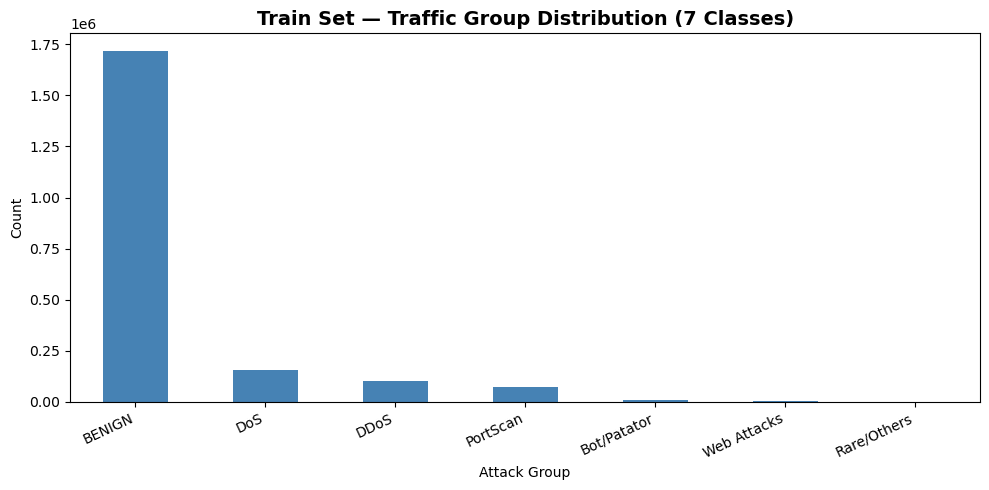

In [5]:
# Original 15-class label names (for reference and distribution plots)
LABEL_MAP_ORIG = {
    0:  'BENIGN',
    1:  'PortScan',
    2:  'Infiltration',
    3:  'Web Attack - Brute Force',
    4:  'Web Attack - XSS',
    5:  'Web Attack - SQL Injection',
    6:  'DDoS',
    7:  'DoS Hulk',
    8:  'DoS GoldenEye',
    9:  'DoS Slowloris',
    10: 'DoS Slowhttptest',
    11: 'FTP-Patator',
    12: 'SSH-Patator',
    13: 'Bot',
    14: 'Heartbleed',
}

# 7-class group mapping: original label → group ID
GROUP_MAP = {
    0:  0,   # BENIGN        → 0: BENIGN
    3:  1,   # Brute Force   → 1: Web Attacks
    4:  1,   # XSS           → 1: Web Attacks
    5:  1,   # SQL Injection → 1: Web Attacks
    7:  2,   # DoS Hulk      → 2: DoS
    8:  2,   # DoS GoldenEye → 2: DoS
    9:  2,   # DoS Slowloris → 2: DoS
    10: 2,   # DoS Slowhttptest → 2: DoS
    6:  3,   # DDoS          → 3: DDoS
    1:  4,   # PortScan      → 4: PortScan
    13: 5,   # Bot           → 5: Bot/Patator
    11: 5,   # FTP-Patator   → 5: Bot/Patator
    12: 5,   # SSH-Patator   → 5: Bot/Patator
    2:  6,   # Infiltration  → 6: Rare/Others
    14: 6,   # Heartbleed    → 6: Rare/Others
}

# Human-readable names for the 7 groups
LABEL_MAP = {
    0: 'BENIGN',
    1: 'Web Attacks',
    2: 'DoS',
    3: 'DDoS',
    4: 'PortScan',
    5: 'Bot/Patator',
    6: 'Rare/Others',
}

NUM_CLASSES = len(LABEL_MAP)  # 7
CLASS_NAMES = [LABEL_MAP[i] for i in sorted(LABEL_MAP)]

# Apply original label names for the distribution plot
df_train['AttackType'] = df_train['Label'].map(LABEL_MAP_ORIG)
df_test['AttackType']  = df_test['Label'].map(LABEL_MAP_ORIG)

# Apply group labels as the new target
df_train['GroupLabel'] = df_train['Label'].map(GROUP_MAP)
df_test['GroupLabel']  = df_test['Label'].map(GROUP_MAP)

print('Train group distribution:')
print(df_train['GroupLabel'].map(LABEL_MAP).value_counts())
print('\nTest group distribution:')
print(df_test['GroupLabel'].map(LABEL_MAP).value_counts())

# Plot grouped distribution
df_train['GroupLabel'].map(LABEL_MAP).value_counts().plot(
    kind='bar', figsize=(10, 5), color='steelblue')
plt.title('Train Set — Traffic Group Distribution (7 Classes)', fontsize=14, fontweight='bold')
plt.xlabel('Attack Group')
plt.ylabel('Count')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150)
plt.show()


## STEP 5 — Clean Both Datasets
Remove unnecessary columns, drop infinities, NaNs, and duplicates.
All 7 groups are retained — no label filtering.


In [6]:
def clean_df(df, name):
    print(f'{name} before cleaning: {df.shape}')
    df.drop(columns=['source', 'AttackType'], inplace=True, errors='ignore')
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)
    df.drop_duplicates(inplace=True)
    print(f'{name} after  cleaning: {df.shape}')
    return df

df_train = clean_df(df_train, 'Train')
df_test  = clean_df(df_test,  'Test')


Train before cleaning: (2059411, 82)
Train after  cleaning: (2023662, 80)
Test before cleaning: (514853, 82)
Test after  cleaning: (511898, 80)


## STEP 6 — Feature Selection

In [7]:
SELECTED_FEATURES = [
    'Flow Duration',
    'Total Fwd Packets',
    'Total Backward Packets',
    'Total Length of Fwd Packets',
    'Total Length of Bwd Packets',
    'Flow Bytes/s',
    'Flow Packets/s',
    'Flow IAT Mean',
    'Flow IAT Std',
    'Fwd IAT Mean',
    'Bwd IAT Mean',
    'Packet Length Mean',
    'Packet Length Std',
    'Destination Port',
    'Average Packet Size',
    'Fwd Packet Length Mean',
    'Bwd Packet Length Mean',
    'Fwd Packets/s',
    'Bwd Packets/s',
    'SYN Flag Count',
    'ACK Flag Count',
    'PSH Flag Count',
    'Init_Win_bytes_forward',
    'Init_Win_bytes_backward',
]

available = [f for f in SELECTED_FEATURES if f in df_train.columns]
missing   = [f for f in SELECTED_FEATURES if f not in df_train.columns]

if missing:
    print(f'Skipped (not in CSV): {missing}')
print(f'Using {len(available)} features.')
print(available)


Using 24 features.
['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Fwd IAT Mean', 'Bwd IAT Mean', 'Packet Length Mean', 'Packet Length Std', 'Destination Port', 'Average Packet Size', 'Fwd Packet Length Mean', 'Bwd Packet Length Mean', 'Fwd Packets/s', 'Bwd Packets/s', 'SYN Flag Count', 'ACK Flag Count', 'PSH Flag Count', 'Init_Win_bytes_forward', 'Init_Win_bytes_backward']


## STEP 7 — Prepare X and y, Scale (No Data Leakage)
Target `y` is the **grouped** 7-class label (0–6).
The scaler is fit on training data only to prevent data leakage.


In [8]:
# Separate features and grouped labels
X_train_raw = df_train[available].values
y_train     = df_train['GroupLabel'].values      # 0–6 grouped classes

X_test_raw  = df_test[available].values
y_test      = df_test['GroupLabel'].values       # 0–6 grouped classes

# Fit scaler on TRAIN only, transform both — no data leakage
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

print(f'Train : {X_train.shape[0]:,} samples, {X_train.shape[1]} features')
print(f'Test  : {X_test.shape[0]:,} samples, {X_test.shape[1]} features')
print(f'Groups in train: {sorted(np.unique(y_train))}')
print(f'Groups in test : {sorted(np.unique(y_test))}')

joblib.dump(scaler,    'scaler.pkl')
joblib.dump(available, 'feature_columns.pkl')
joblib.dump(LABEL_MAP, 'label_map.pkl')
joblib.dump(GROUP_MAP, 'group_map.pkl')
print('\nscaler.pkl saved')
print('feature_columns.pkl saved')
print('label_map.pkl saved')
print('group_map.pkl saved')

# Save scaled arrays to disk for resume capability
import numpy as np
np.save('X_train.npy', X_train)
np.save('y_train.npy', y_train)
np.save('X_test.npy',  X_test)
np.save('y_test.npy',  y_test)
print('X_train.npy / y_train.npy / X_test.npy / y_test.npy saved')


Train : 2,023,662 samples, 24 features
Test  : 511,898 samples, 24 features
Groups in train: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Groups in test : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]

scaler.pkl saved
feature_columns.pkl saved
label_map.pkl saved
group_map.pkl saved
X_train.npy / y_train.npy / X_test.npy / y_test.npy saved


## STEP 8 — Class Imbalance Strategy
Instead of SMOTE, `class_weight='balanced'` is passed directly to LR and RF.  
This tells each model to weight rare-class errors more heavily during training — no synthetic data generated, faster training, lower RAM, better real-world generalisation.  
XGBoost uses `sample_weight` computed from class frequencies for the same effect.

In [9]:
from sklearn.utils.class_weight import compute_sample_weight

# Compute sample weights for XGBoost (LR and RF use class_weight='balanced' directly)
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# Alias so all downstream code (eval, viz, resume) uses consistent names
X_train_bal = X_train
y_train_bal = y_train

print('Class imbalance handled via class_weight — no SMOTE applied.')
print(f'Training set: {X_train_bal.shape[0]:,} samples (original, unmodified)')
print(f'Class distribution: {dict(zip(*np.unique(y_train, return_counts=True)))}')


Class imbalance handled via class_weight — no SMOTE applied.
Training set: 2,023,662 samples (original, unmodified)
Class distribution: {np.int64(0): np.int64(1682960), np.int64(1): np.int64(1715), np.int64(2): np.int64(154998), np.int64(3): np.int64(102413), np.int64(4): np.int64(72655), np.int64(5): np.int64(8883), np.int64(6): np.int64(38)}


## STEP 9 — Train Supervised Models (7-Class)
All three supervised models are configured for 7-class (grouped) classification.
- **Logistic Regression** — baseline, `saga` solver, `multi_class='multinomial'`
- **Random Forest** — main classifier, handles multiclass natively
- **XGBoost** — advanced classifier with `objective='multi:softprob'`


In [10]:
NUM_CLASSES = len(LABEL_MAP)  # 7

# ── Logistic Regression (Baseline) ───────────────────────────────────────
# v6: switched to saga solver — much faster & lower RAM on large datasets.
# saga handles multiclass natively (multinomial by default), supports n_jobs,
# and converges reliably with far fewer iterations than lbfgs.
print('Training Logistic Regression (multiclass)...')
lr = LogisticRegression(max_iter=500, solver='saga', tol=1e-3,
                        class_weight='balanced', n_jobs=-1, random_state=42)
lr.fit(X_train_bal, y_train_bal)
lr_pred  = lr.predict(X_test)
lr_proba = lr.predict_proba(X_test)      # shape (n_samples, 15)
print(f'  Accuracy: {accuracy_score(y_test, lr_pred):.4f}')
joblib.dump(lr, 'logistic_regression_model.pkl'); print('  → logistic_regression_model.pkl saved')

# ── Random Forest (Main Classifier) ──────────────────────────────────────
print('\nTraining Random Forest (multiclass)...')
rf = RandomForestClassifier(n_estimators=50, class_weight='balanced',
                            random_state=42, n_jobs=-1)
rf.fit(X_train_bal, y_train_bal)
rf_pred  = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)      # shape (n_samples, 15)
print(f'  Accuracy: {accuracy_score(y_test, rf_pred):.4f}')
joblib.dump(rf, 'random_forest_model.pkl'); print('  → random_forest_model.pkl saved')

# ── XGBoost (Advanced) ───────────────────────────────────────────────────
if XGBOOST_AVAILABLE:
    print('\nTraining XGBoost (multiclass)...')
    xgb = XGBClassifier(
        objective='multi:softprob',
        num_class=NUM_CLASSES,
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1
    )
    xgb.fit(X_train_bal, y_train_bal, sample_weight=sample_weights)
    xgb_pred  = xgb.predict(X_test)
    xgb_proba = xgb.predict_proba(X_test)   # shape (n_samples, 15)
    print(f'  Accuracy: {accuracy_score(y_test, xgb_pred):.4f}')
    joblib.dump(xgb, 'xgboost_model.pkl'); print('  → xgboost_model.pkl saved')

print('\n✅ Supervised models trained!')


Training Logistic Regression (multiclass)...
  Accuracy: 0.8018
  → logistic_regression_model.pkl saved

Training Random Forest (multiclass)...
  Accuracy: 0.9985
  → random_forest_model.pkl saved

Training XGBoost (multiclass)...
  Accuracy: 0.9986
  → xgboost_model.pkl saved

✅ Supervised models trained!


## STEP 10 — Train Isolation Forest (Anomaly Detector)
Isolation Forest is trained on BENIGN-only traffic and flags anomalies.
In multiclass context it acts as a binary anomaly signal alongside the 15-class classifiers.

In [11]:
# Train on BENIGN rows from training set only
X_train_benign = X_train[y_train == 0]
print(f'Training Isolation Forest on {X_train_benign.shape[0]:,} BENIGN samples...')

iso = IsolationForest(contamination=0.05, random_state=42, n_jobs=-1)
iso.fit(X_train_benign)

iso_raw  = iso.predict(X_test)
iso_pred = np.where(iso_raw == -1, 1, 0)   # -1=anomaly→1, 1=normal→0
iso_score = -iso.score_samples(X_test)      # higher = more anomalous

# For Isolation Forest, map binary predictions to class 0 (BENIGN) or -1 (unknown attack)
# Report accuracy against a binary view (0=benign, 1=any attack)
y_test_binary = (y_test != 0).astype(int)
print(f'Anomaly detection accuracy (binary): {accuracy_score(y_test_binary, iso_pred):.4f}')
print('Note: Isolation Forest outputs binary (BENIGN/anomaly), not 15 classes.')
joblib.dump(iso, 'isolation_forest_model.pkl'); print('  → isolation_forest_model.pkl saved')


Training Isolation Forest on 1,682,960 BENIGN samples...
Anomaly detection accuracy (binary): 0.8869
Note: Isolation Forest outputs binary (BENIGN/anomaly), not 15 classes.
  → isolation_forest_model.pkl saved


## STEP 11 — Full Evaluation Reports (7-Class)
Per-class precision, recall, and F1-score for all 7 traffic groups.


In [12]:
def evaluate(name, y_true, y_pred, target_names=None):
    print(f'\n{"="*65}')
    print(f'  {name}')
    print(f'{"="*65}')
    print(classification_report(y_true, y_pred, target_names=target_names,
                                 zero_division=0))

evaluate('Logistic Regression (Baseline)', y_test, lr_pred,  CLASS_NAMES)
evaluate('Random Forest (Main)',           y_test, rf_pred,  CLASS_NAMES)
if XGBOOST_AVAILABLE:
    evaluate('XGBoost (Advanced)',         y_test, xgb_pred, CLASS_NAMES)



  Logistic Regression (Baseline)
              precision    recall  f1-score   support

      BENIGN       0.99      0.78      0.87    426722
 Web Attacks       0.02      0.88      0.04       428
         DoS       0.84      0.86      0.85     38750
        DDoS       0.50      0.95      0.66     25603
    PortScan       0.60      0.98      0.74     18164
 Bot/Patator       0.06      0.87      0.12      2222
 Rare/Others       0.00      0.89      0.00         9

    accuracy                           0.80    511898
   macro avg       0.43      0.89      0.47    511898
weighted avg       0.94      0.80      0.85    511898


  Random Forest (Main)
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00    426722
 Web Attacks       1.00      0.93      0.96       428
         DoS       1.00      1.00      1.00     38750
        DDoS       1.00      1.00      1.00     25603
    PortScan       0.99      0.99      0.99     18164
 Bot/Patator       0

## STEP 12 — Model Comparison Table
Macro-averaged precision, recall, and F1-score across all 7 groups.
ROC-AUC is computed using the one-vs-rest (OvR) strategy.


In [13]:
def get_metrics(y_true, y_pred, y_proba=None):
    row = {
        'Accuracy (%)':  round(accuracy_score(y_true, y_pred) * 100, 2),
        'Precision (%)': round(precision_score(y_true, y_pred, average='macro', zero_division=0) * 100, 2),
        'Recall (%)':    round(recall_score(y_true, y_pred, average='macro', zero_division=0) * 100, 2),
        'F1-Score (%)':  round(f1_score(y_true, y_pred, average='macro', zero_division=0) * 100, 2),
    }
    if y_proba is not None:
        # OvR ROC-AUC for multiclass
        try:
            row['ROC-AUC (OvR)'] = round(
                roc_auc_score(y_true, y_proba, multi_class='ovr',
                              average='macro', labels=list(range(7))), 4
            )
        except Exception as e:
            row['ROC-AUC (OvR)'] = float('nan')
            print(f'  ROC-AUC skipped: {e}')
    return row

results = {
    'Logistic Regression': get_metrics(y_test, lr_pred, lr_proba),
    'Random Forest':       get_metrics(y_test, rf_pred, rf_proba),
}
if XGBOOST_AVAILABLE:
    results['XGBoost'] = get_metrics(y_test, xgb_pred, xgb_proba)

results_df = pd.DataFrame(results).T
print('\n📊 Model Comparison Table (macro-averaged over 7 groups)')
print(results_df.to_string())

results_df.to_csv('model_comparison.csv')
print('\nSaved: model_comparison.csv')



📊 Model Comparison Table (macro-averaged over 7 groups)
                     Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)  ROC-AUC (OvR)
Logistic Regression         80.18          43.01       88.73         46.84         0.9752
Random Forest               99.85          99.43       95.03         97.02         0.9988
XGBoost                     99.86          94.91       98.11         96.18         1.0000

Saved: model_comparison.csv


## STEP 13 — Visualisations

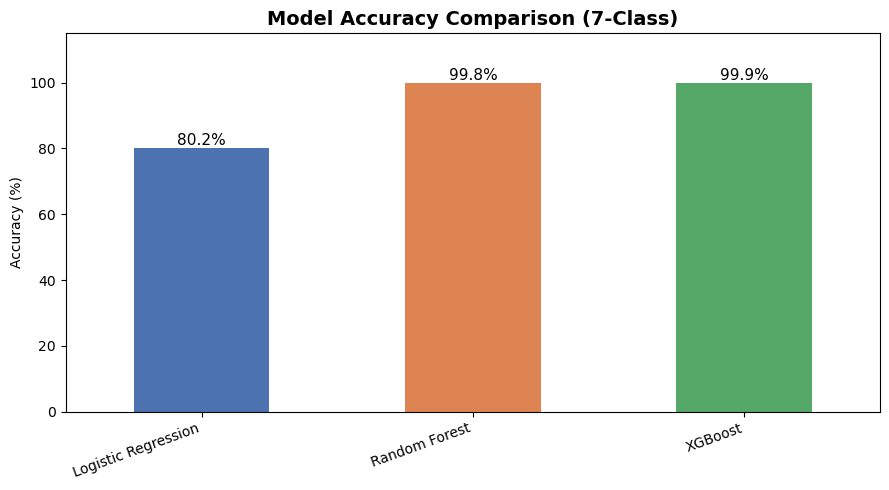

In [14]:
COLORS = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

# ── Accuracy Bar Chart ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
results_df['Accuracy (%)'].plot(kind='bar', ax=ax,
                                 color=COLORS[:len(results_df)])
ax.set_title('Model Accuracy Comparison (7-Class)', fontsize=14, fontweight='bold')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 115)
ax.set_xticklabels(results_df.index, rotation=20, ha='right')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.savefig('accuracy_comparison.png', dpi=150)
plt.show()


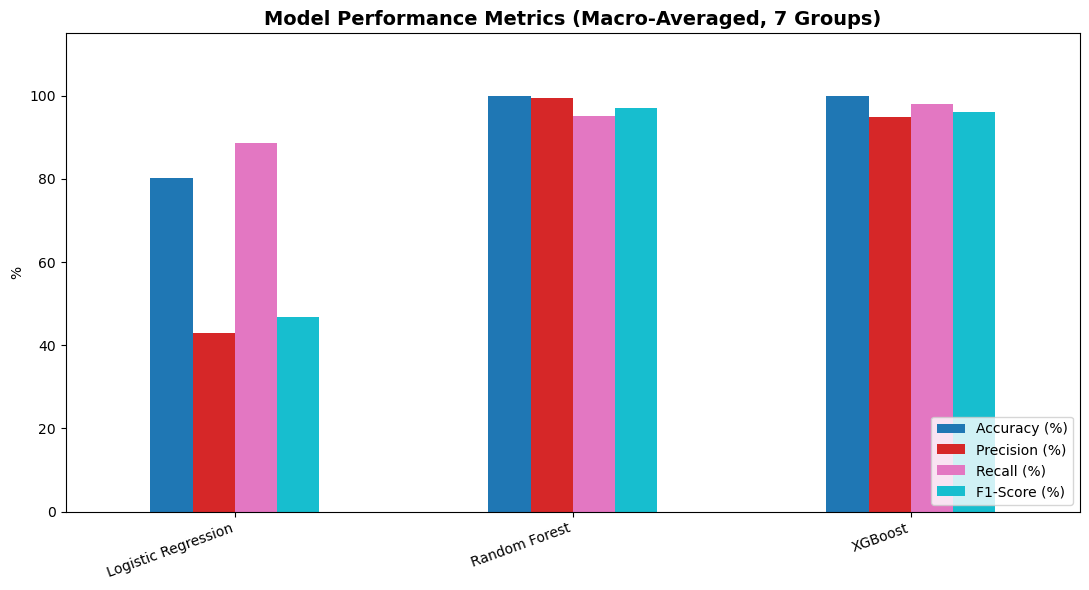

In [15]:
# ── All Metrics Grouped Bar ───────────────────────────────────────────────
plot_cols = ['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)']
results_df[plot_cols].plot(kind='bar', figsize=(11, 6), colormap='tab10')
plt.title('Model Performance Metrics (Macro-Averaged, 7 Groups)',
          fontsize=14, fontweight='bold')
plt.ylabel('%')
plt.ylim(0, 115)
plt.xticks(rotation=20, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=150)
plt.show()


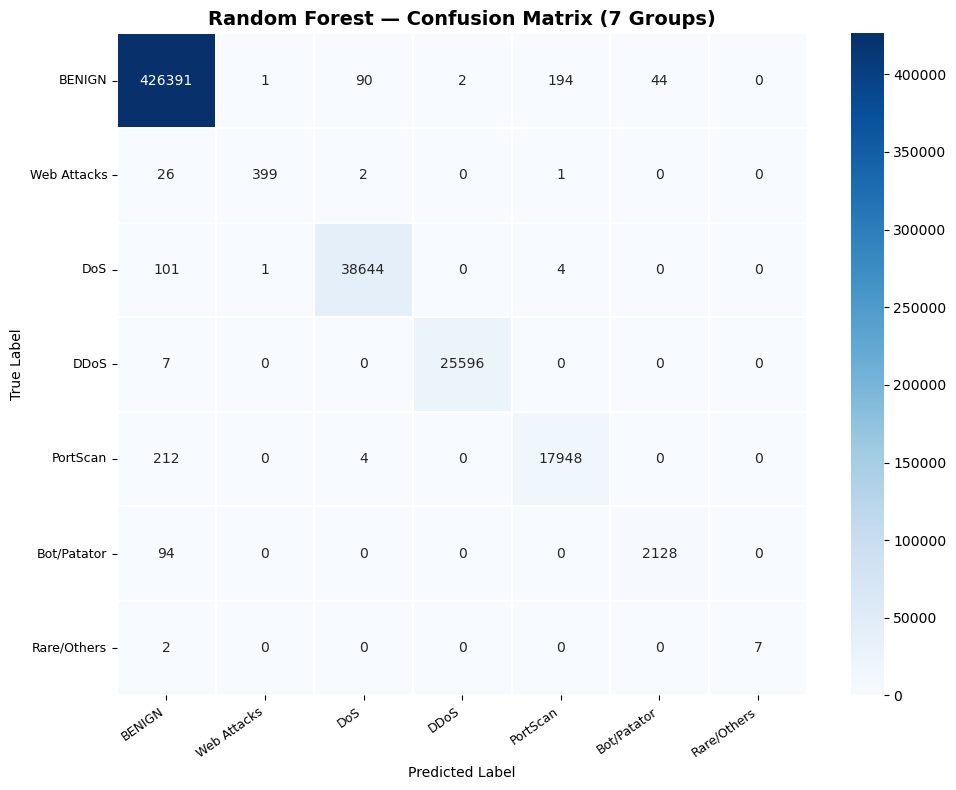

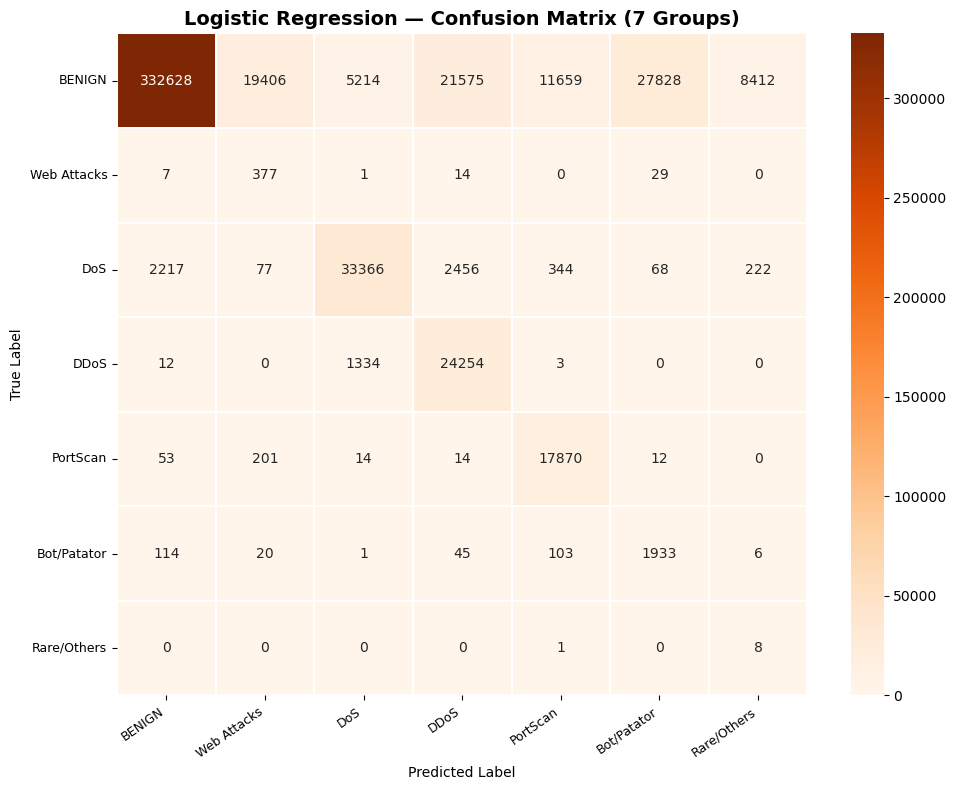

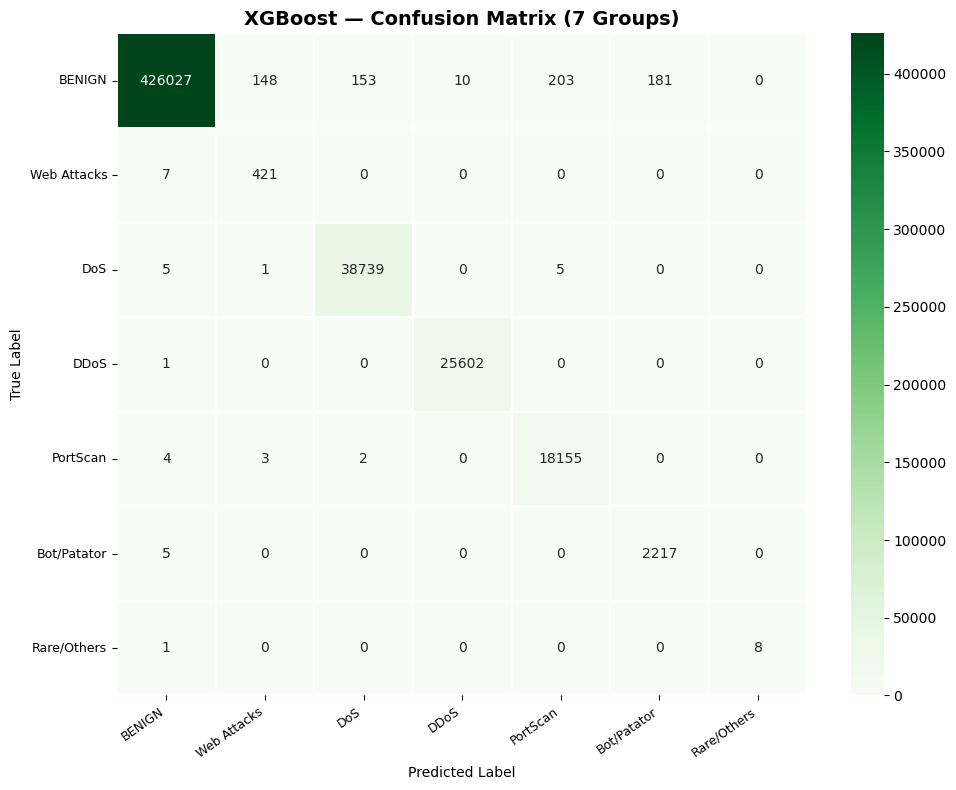

In [16]:
# ── Confusion Matrix — Random Forest (15×15) ─────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(y_test, rf_pred, labels=list(range(7)))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=ax, linewidths=0.3)
ax.set_title('Random Forest — Confusion Matrix (7 Groups)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.xticks(rotation=35, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('confusion_matrix_rf.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Confusion Matrix — Logistic Regression ───────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
cm_lr = confusion_matrix(y_test, lr_pred, labels=list(range(7)))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Oranges',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=ax, linewidths=0.3)
ax.set_title('Logistic Regression — Confusion Matrix (7 Groups)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.xticks(rotation=35, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('confusion_matrix_lr.png', dpi=150, bbox_inches='tight')
plt.show()

if XGBOOST_AVAILABLE:
    fig, ax = plt.subplots(figsize=(10, 8))
    cm_xgb = confusion_matrix(y_test, xgb_pred, labels=list(range(7)))
    sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, linewidths=0.3)
    ax.set_title('XGBoost — Confusion Matrix (7 Groups)',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    plt.xticks(rotation=35, ha='right', fontsize=9)
    plt.yticks(rotation=0, fontsize=9)
    plt.tight_layout()
    plt.savefig('confusion_matrix_xgb.png', dpi=150, bbox_inches='tight')
    plt.show()


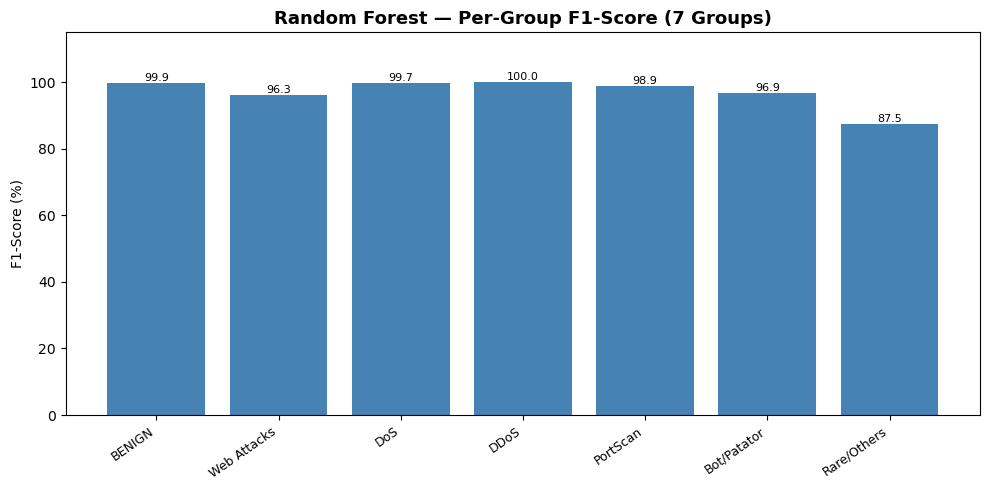

In [17]:
# ── Per-Class F1-Score Bar Chart (Random Forest) ─────────────────────────
rf_f1_per_class = f1_score(y_test, rf_pred, average=None,
                            labels=list(range(7)), zero_division=0)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(CLASS_NAMES, rf_f1_per_class * 100, color='steelblue')
ax.set_title('Random Forest — Per-Group F1-Score (7 Groups)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('F1-Score (%)')
ax.set_ylim(0, 115)
plt.xticks(rotation=35, ha='right', fontsize=9)
for bar, val in zip(bars, rf_f1_per_class):
    ax.annotate(f'{val*100:.1f}',
                (bar.get_x() + bar.get_width() / 2., bar.get_height()),
                ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('f1_per_class_rf.png', dpi=150)
plt.show()


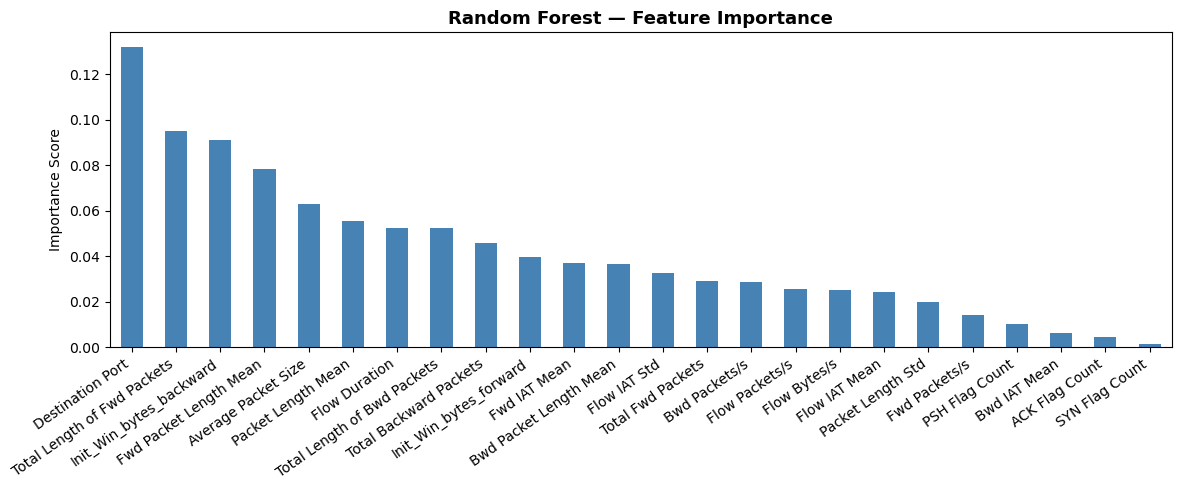

Top 5 most important features:
Destination Port               0.131714
Total Length of Fwd Packets    0.095115
Init_Win_bytes_backward        0.091090
Fwd Packet Length Mean         0.078305
Average Packet Size            0.062822
dtype: float64


In [18]:
# ── Feature Importance (Random Forest) ───────────────────────────────────
feat_imp = pd.Series(rf.feature_importances_, index=available).sort_values(ascending=False)

feat_imp.plot(kind='bar', figsize=(12, 5), color='steelblue')
plt.title('Random Forest — Feature Importance', fontsize=13, fontweight='bold')
plt.ylabel('Importance Score')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print('Top 5 most important features:')
print(feat_imp.head())


## STEP 14 — Save All Models

In [19]:
joblib.dump(lr,         'logistic_regression_model.pkl')
joblib.dump(rf,         'random_forest_model.pkl')
joblib.dump(iso,        'isolation_forest_model.pkl')
joblib.dump(scaler,     'scaler.pkl')
joblib.dump(available,  'feature_columns.pkl')
joblib.dump(LABEL_MAP,  'label_map.pkl')
joblib.dump(GROUP_MAP,  'group_map.pkl')
joblib.dump(CLASS_NAMES,'class_names.pkl')

if XGBOOST_AVAILABLE:
    joblib.dump(xgb, 'xgboost_model.pkl')

print('✅ All models saved:')
print('   logistic_regression_model.pkl')
print('   random_forest_model.pkl')
print('   isolation_forest_model.pkl')
print('   scaler.pkl')
print('   feature_columns.pkl')
print('   label_map.pkl')
print('   group_map.pkl')
print('   class_names.pkl')
if XGBOOST_AVAILABLE:
    print('   xgboost_model.pkl')


✅ All models saved:
   logistic_regression_model.pkl
   random_forest_model.pkl
   isolation_forest_model.pkl
   scaler.pkl
   feature_columns.pkl
   label_map.pkl
   group_map.pkl
   class_names.pkl
   xgboost_model.pkl


## STEP 15 — Live Prediction Test (Flask dry-run)
Simulates how Flask will load the saved model, scale a raw input, and return
the predicted **attack group** (one of 7 classes) plus confidence score.


In [22]:
# Simulate what Flask will do: load saved model, scale input, predict
loaded_rf        = joblib.load('random_forest_model.pkl')
loaded_scaler    = joblib.load('scaler.pkl')
loaded_features  = joblib.load('feature_columns.pkl')
loaded_label_map = joblib.load('label_map.pkl')

# Take 10 raw (unscaled) samples from test set
sample_raw = X_test_raw[:100]
sample_y   = y_test[:100]

# Scale using saved scaler
sample_scaled = loaded_scaler.transform(sample_raw)
preds  = loaded_rf.predict(sample_scaled)
probas = loaded_rf.predict_proba(sample_scaled)   # shape (10, 15)

print('Live Prediction Test — Random Forest (7-Class Groups)')
print('-' * 65)
for i, (actual, pred, proba_row) in enumerate(zip(sample_y, preds, probas)):
    actual_name = loaded_label_map[actual]
    pred_name   = loaded_label_map[pred]
    confidence  = proba_row[pred] * 100
    status = '✓' if actual == pred else '✗'
    print(f'  [{status}] Row {i+1:2d}: Actual={actual_name:30s}  '
          f'Predicted={pred_name:30s}  Confidence={confidence:.1f}%')


Live Prediction Test — Random Forest (7-Class Groups)
-----------------------------------------------------------------
  [✓] Row  1: Actual=BENIGN                          Predicted=BENIGN                          Confidence=100.0%
  [✓] Row  2: Actual=BENIGN                          Predicted=BENIGN                          Confidence=100.0%
  [✓] Row  3: Actual=BENIGN                          Predicted=BENIGN                          Confidence=100.0%
  [✓] Row  4: Actual=BENIGN                          Predicted=BENIGN                          Confidence=100.0%
  [✓] Row  5: Actual=BENIGN                          Predicted=BENIGN                          Confidence=100.0%
  [✓] Row  6: Actual=BENIGN                          Predicted=BENIGN                          Confidence=100.0%
  [✓] Row  7: Actual=BENIGN                          Predicted=BENIGN                          Confidence=100.0%
  [✓] Row  8: Actual=BENIGN                          Predicted=BENIGN                    

---
## ✅ Output Files
| File | Purpose |
|------|---------|
| `random_forest_model.pkl` | Main 7-class classifier → Flask |
| `isolation_forest_model.pkl` | Anomaly detector → Flask |
| `logistic_regression_model.pkl` | Baseline comparison |
| `xgboost_model.pkl` | Advanced comparison |
| `scaler.pkl` | Fit on train only — no leakage |
| `feature_columns.pkl` | Feature order for Flask |
| `label_map.pkl` | Group ID → group name for Flask |
| `group_map.pkl` | Original label → group ID |
| `class_names.pkl` | Ordered list of 7 group names |
| `model_comparison.csv` | Paste into report |
| `accuracy_comparison.png` | Model accuracy chart |
| `metrics_comparison.png` | All macro-averaged metrics chart |
| `confusion_matrix_rf.png` | Random Forest 7×7 confusion matrix |
| `confusion_matrix_lr.png` | Logistic Regression 7×7 confusion matrix |
| `confusion_matrix_xgb.png` | XGBoost 7×7 confusion matrix |
| `f1_per_class_rf.png` | Per-group F1 bar chart (RF) |
| `feature_importance.png` | RF feature importance |
| `label_distribution.png` | Dataset group distribution |
